**뉴런** = 신경망의 가장 기본적인 구성요소,  입력을 받아 계산 후 출력을 반환

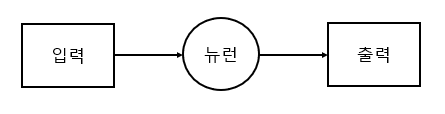

**신경망** = 뉴런이 여러개 모여 레이어(layer)를 구성하고, 레이어가 모여 구성된 형태

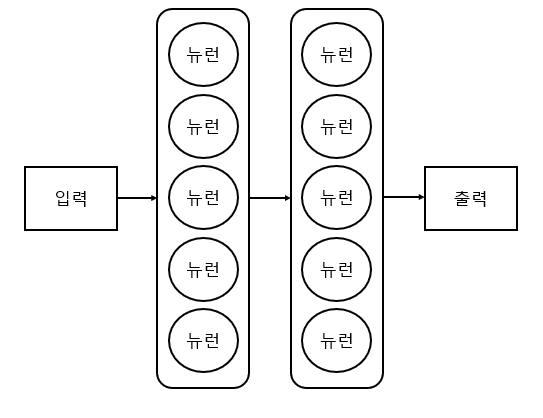

뉴런은 입력, 가중치, 활성화 함수, 출력으로 구성된다.

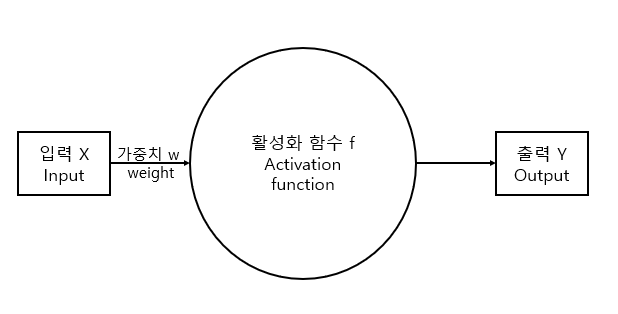

입력, 가중치, 출력은 보통 정수나 float가 많이 쓰인다.  
**활성화 함수** = 뉴런의 출력값을 정하는 함수  
가장 간단한 형태의 뉴런은 입력에 가중치를 곱한 뒤, 활성화 함수를 취하면 출력을 얻을 수 있다.

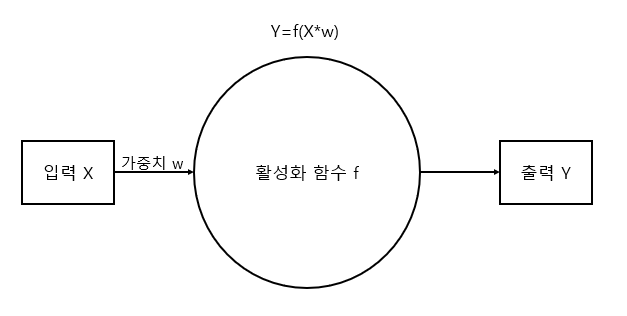

뉴런에서 학습할 때 변하는 것은 가중치이다.  
가중치는 처음에는 초기화를 통해 랜덤한 값을 넣고, 학습 과정에서 점차 일정한 값으로 수렴한다.  
학습이 잘 된다는 것은 좋은 가중치를 얻어서 원하는 출력에 가까운 값을 얻는것이라 할 수 있다. 

활성화함수로는 시그모이드(sigmoid), ReLU 등을 주로 쓰게된다.  
___
**시그모이드** = S자 형태의 곡선이 라는 뜻  
___
**ReLU** = Rectified Linear Unit의 약자, 정류된 선형 함수라는 뜻  
___
딥러닝에서 선형 함수는 y = x 라는 식으로 정의할 수 있는 입력과 출력이 동일한 함수를 의미한다.  
이 함수를 정류해서 음수 값을 0으로 만든 것이 ReLU이다.  


신경망 초창기에는 시그모이드가 주로 쓰였으나 은닉층을 다수 사용하는 딥러닝 시대가 되면서  
ReLU가 더 많이 쓰이는 추세이다. 
시그모이드는 출력값을 0~1 사이로만 제한하게 되지만  
ReLU는 양수를 그대로 반환하기 때문에 값의 왜곡이 적어진다.  

In [2]:
# 시그모이드 함수 구현
import math
def sigmoid(x):
  return 1 / (1 + math.exp(-x))

첫 번째 줄 > math 모듈 불러오기, math 모듈은 상수 e의 제곱을 계산하기 위한 math.exp()를 사용하는데 필요   
두 번째 줄 > sigmoid() 함수 정의 및 x를 입력으로 받음  
세 번째 줄 > 1/ (1 + math.exp(-x)) = 시그모이드 함수를 취한 값을 반환 

In [3]:
import tensorflow as tf
# 뉴런의 입력과 출력 정의, 입력이 1일 때 기대출력이 0이 되는 뉴런
x = 1
y = 0
w = tf.random.normal([1],0,1)
output = sigmoid(x * w)
print(output)

0.6626689815903514


입력 x 에는 1을 넣고 가중치는 w로 정규 분포의 랜덤한 값을 넣는다.  
실제 출력인 output은 sigmoid() 함수에 입력과 출력을 곱한 값을 넣어서 계산한다.  


**에러** = 실제 출력으로 나온 0.66266과 기대 출력 0의 차이인 0 - 0.43007 = -0.43007
___  
뉴런의 학습은 이 에러가 0에 가까워지게 해서 출력으로 기대값에 가까운 값을 얻는 것  
뉴런 = w값 이며 w를 변화시켜야 하는데 경사 하강법 이라는 방법을 사용한다  
___
**경사 하강법** = w에 입력과 학습률과 에러를 곱한 값을 더해주는것
___
학습률은 w를 업데이트하는 정도로, 큰 값으로 설정하면 학습이 빨리 되지만 과도한 학습으로 적정 수치를 벗어날 우려가 있고  
너무 작은 값으로 설정하면 학습 시간이 오래 걸린다.  
여기서는 학습률 = 0.1 정도로 설정한다

In [4]:
for i in range(1000):
  output = sigmoid(x * w)
  error = y - output
  w = w + x * 0.1 * error

  if i % 100 == 99:
    print(i, error, output)

99 -0.11400257565489802 0.11400257565489802
199 -0.0554825328648432 0.0554825328648432
299 -0.03623349951440477 0.03623349951440477
399 -0.026807626879779226 0.026807626879779226
499 -0.021242221424702192 0.021242221424702192
599 -0.01757703971390079 0.01757703971390079
699 -0.014983933343726252 0.014983933343726252
799 -0.01305395357197155 0.01305395357197155
899 -0.011562235845628821 0.011562235845628821
999 -0.010375116327915254 0.010375116327915254


error 값은 0에 점점 가까워지고, output도 기대출력인 0에 가까워지는것을 확인 가능하다.

그렇다면 입력이 0, 출력이 1을 얻는 뉴런은 같은 방식으로 가능할까?

In [5]:
x = 0
y = 1
w = tf.random.normal([1],0,1)

for i in range(1000):
  output = sigmoid(x * w)
  error = y - output
  w = w + x * 0.1 * error

  if i % 100 == 99:
    print(i, error, output)

99 0.5 0.5
199 0.5 0.5
299 0.5 0.5
399 0.5 0.5
499 0.5 0.5
599 0.5 0.5
699 0.5 0.5
799 0.5 0.5
899 0.5 0.5
999 0.5 0.5


error는 변하지 않고 출력도 0.5로 동일하게 출력된다.  
경사 하강법의 업데이트 식은 w = w + 입력값 X 학습률 X 에러이다  
입력값이 0이라 w에 더해지는 값은 없다, 결국 1000번 실행할 동안 w값은 변하지 않는다.  
이를 방지하기 위해 편향(bias) 라는 것을 뉴런에 넣어준다  
___
편향(bias) = 입력으로 늘 한쪽으로 치우친 고정된 값을 받는다  
___
입력으로 0을 받았을 때 뉴런이 아무것도 배우지 못하는 상황을 방지한다  
편향은 w 처럼 난수로 초기화 되며 뉴런에 더해져 출력을 계산하게 된다  

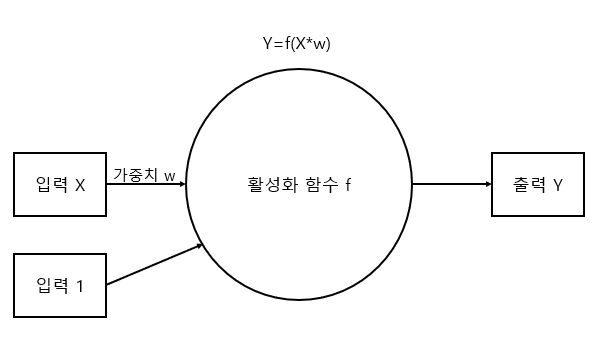

In [6]:
x = 0
y = 1
w = tf.random.normal([1],0,1)
b = tf.random.normal([1],0,1) # 편향(bias)

for i in range(1000):
  output = sigmoid(x * w + 1 * b) # 각 입력에 가중치와 편향을 곱해서 더해준다
  error = y - output
  w = w + x * 0.1 * error
  b = b + 1 * 0.1 * error

  if i % 100 == 99:
    print(i, error, output)

99 0.13778425763794067 0.8622157423620593
199 0.06098251196187743 0.9390174880381226
299 0.03855210347571025 0.9614478965242897
399 0.028068888509036882 0.9719311114909631
499 0.022031098005770744 0.9779689019942293
599 0.018115766052456794 0.9818842339475432
699 0.015374722703051846 0.9846252772969482
799 0.013350141257122194 0.9866498587428778
899 0.01179434860895967 0.9882056513910403
999 0.010561854415110483 0.9894381455848895


그 결과, error는 0에 가까운 값이 나오고, output은 1에 가깝게 출력되는 것을 확인할 수 있다